# Redes Neuronales

In [164]:
#!pip install tensorflow

In [165]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')

from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, 
                             ConfusionMatrixDisplay, precision_recall_curve, 
                             roc_auc_score, roc_curve)

np.random.seed(42)
tf.random.set_seed(42)
print(f"TensorFlow: {tf.__version__}")

TensorFlow: 2.20.0


In [166]:
# Datos
df = pd.read_excel('../../data_cleaned.xlsx')
X_text = df['Hallazgos'].astype(str).values

patologias = ['hemorragia', 'acv', 'fractura', 'masa']
y = df[patologias].values

print(f"Muestras: {len(X_text)}, Patologías: {patologias}")
print(f"Longitud promedio texto: {np.mean([len(t.split()) for t in X_text]):.0f} palabras")

Muestras: 895, Patologías: ['hemorragia', 'acv', 'fractura', 'masa']
Longitud promedio texto: 151 palabras


In [167]:
# Hiperparámetros optimizados para Hallazgos
# ============================================================
TEXT    = "Hallazgos"
VOCAB   = 12000
MAXLEN  = 200
EMB_DIM = 100
BATCH   = 16
EPOCHS  = 20

# Etiquetas descriptivas por patología
ETIQUETAS = {
    'hemorragia': ['Sin hemorragia', 'Hemorragia'],
    'acv':        ['Sin ACV', 'ACV'],
    'fractura':   ['Sin fractura', 'Fractura'],
    'masa':       ['Sin masa', 'Masa']
}

In [168]:
from tensorflow.keras.layers import SpatialDropout1D

def build_lstm(vocab=VOCAB, maxlen=MAXLEN, emb_dim=EMB_DIM):
    """
    Arquitectura mejorada para texto combinado:
    - SpatialDropout1D después de Embedding (regulariza embeddings)
    - LSTM más amplio (64→32) para capturar patrones complejos
    - Dropout 0.3 (menos agresivo, texto más rico)
    """
    model = Sequential([
        Embedding(vocab, emb_dim, input_length=maxlen),
        SpatialDropout1D(0.2),
        Bidirectional(LSTM(64, return_sequences=True)),
        Dropout(0.3),
        Bidirectional(LSTM(32)),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

def prep_text(train_text, test_text, vocab=VOCAB, maxlen=MAXLEN):
    tok = Tokenizer(num_words=vocab, oov_token="<OOV>")
    tok.fit_on_texts(train_text)
    Xtr = pad_sequences(tok.texts_to_sequences(train_text), maxlen=maxlen, padding="post")
    Xte = pad_sequences(tok.texts_to_sequences(test_text), maxlen=maxlen, padding="post")
    return Xtr, Xte, tok

## Definición Modelo

In [169]:
def train_and_eval(name, X_train, X_test, y_train, y_test):
    """Entrena y evalúa modelo con etiquetas descriptivas por patología"""
    print(f"\n{'='*60}")
    print(f">>> {name.upper()} <<<")
    print(f"{'='*60}")
    
    # Mostrar distribución de clases
    pos_train = y_train.sum()
    neg_train = len(y_train) - pos_train
    print(f"Train: {neg_train} negativos, {pos_train} positivos ({pos_train/len(y_train)*100:.1f}%)")
    
    # Etiquetas específicas para esta patología
    etiquetas = ETIQUETAS.get(name, ['Negativo', 'Positivo'])
    
    model = build_lstm()
    es = EarlyStopping(patience=4, restore_best_weights=True, verbose=1)
    
    history = model.fit(
        X_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH,
        validation_split=0.15,
        callbacks=[es],
        verbose=2
    )
    
    y_prob = model.predict(X_test, batch_size=BATCH).ravel()
    prec, rec, thr = precision_recall_curve(y_test, y_prob)
    f1 = 2 * prec * rec / (prec + rec + 1e-9)
    best_thr = thr[np.nanargmax(f1)]
    y_pred = (y_prob >= best_thr).astype(int)
    
    print(f"\nUmbral óptimo F1: {best_thr:.3f}\n")
    print(classification_report(y_test, y_pred, target_names=etiquetas, digits=3))
    
    # Matriz de confusión con etiquetas descriptivas
    cm = confusion_matrix(y_test, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    ConfusionMatrixDisplay(cm, display_labels=etiquetas).plot(ax=axes[0], cmap="Blues")
    axes[0].set_title(f"Matriz de Confusión - {name.capitalize()}")
    
    # Curva ROC
    auc = roc_auc_score(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f"AUC = {auc:.3f}")
    axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5)
    axes[1].set_xlabel("Tasa Falsos Positivos")
    axes[1].set_ylabel("Tasa Verdaderos Positivos")
    axes[1].set_title(f"Curva ROC - {name.capitalize()}")
    axes[1].legend(loc="lower right")
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # F1 por clase
    f1_neg = 2*cm[0,0] / (2*cm[0,0] + cm[0,1] + cm[1,0]) if (2*cm[0,0] + cm[0,1] + cm[1,0]) > 0 else 0
    f1_pos = 2*cm[1,1] / (2*cm[1,1] + cm[0,1] + cm[1,0]) if (2*cm[1,1] + cm[0,1] + cm[1,0]) > 0 else 0
    
    return model, best_thr, {
        'AUC': auc, 
        'F1_pos': f1_pos, 
        'F1_neg': f1_neg,
        'history': history
    }

In [170]:
# Split datos
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42
)
X_train, X_test, tokenizer = prep_text(X_train_text, X_test_text)
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

Train: 716, Test: 179



>>> HEMORRAGIA <<<
Train: 137 negativos, 579 positivos (80.9%)
Epoch 1/20
38/38 - 36s - 935ms/step - accuracy: 0.7845 - loss: 0.5395 - val_accuracy: 0.8519 - val_loss: 0.4262
Epoch 2/20
38/38 - 26s - 681ms/step - accuracy: 0.8076 - loss: 0.4086 - val_accuracy: 0.8148 - val_loss: 0.3592
Epoch 3/20
38/38 - 7s - 186ms/step - accuracy: 0.8701 - loss: 0.2792 - val_accuracy: 0.8426 - val_loss: 0.3923
Epoch 4/20
38/38 - 8s - 205ms/step - accuracy: 0.9342 - loss: 0.1698 - val_accuracy: 0.8981 - val_loss: 0.3683
Epoch 5/20
38/38 - 7s - 194ms/step - accuracy: 0.9720 - loss: 0.1078 - val_accuracy: 0.9074 - val_loss: 0.3450
Epoch 6/20
38/38 - 8s - 222ms/step - accuracy: 0.9688 - loss: 0.0969 - val_accuracy: 0.8704 - val_loss: 0.4570
Epoch 7/20
38/38 - 9s - 234ms/step - accuracy: 0.9819 - loss: 0.0649 - val_accuracy: 0.9167 - val_loss: 0.4042
Epoch 8/20
38/38 - 7s - 195ms/step - accuracy: 0.9852 - loss: 0.0482 - val_accuracy: 0.8889 - val_loss: 0.4327
Epoch 9/20
38/38 - 7s - 188ms/step - accuracy:

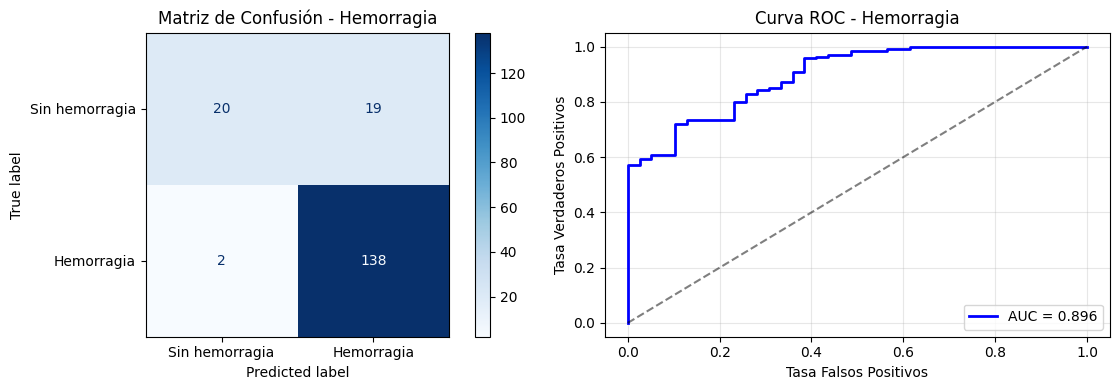


>>> ACV <<<
Train: 399 negativos, 317 positivos (44.3%)
Epoch 1/20
38/38 - 13s - 330ms/step - accuracy: 0.6941 - loss: 0.5920 - val_accuracy: 0.8056 - val_loss: 0.4078
Epoch 2/20
38/38 - 9s - 237ms/step - accuracy: 0.8783 - loss: 0.3237 - val_accuracy: 0.8519 - val_loss: 0.3786
Epoch 3/20
38/38 - 10s - 251ms/step - accuracy: 0.9194 - loss: 0.2242 - val_accuracy: 0.8796 - val_loss: 0.3252
Epoch 4/20
38/38 - 10s - 275ms/step - accuracy: 0.9490 - loss: 0.1581 - val_accuracy: 0.8611 - val_loss: 0.3684
Epoch 5/20
38/38 - 10s - 267ms/step - accuracy: 0.9819 - loss: 0.0759 - val_accuracy: 0.8241 - val_loss: 0.5453
Epoch 6/20
38/38 - 10s - 259ms/step - accuracy: 0.9901 - loss: 0.0353 - val_accuracy: 0.7870 - val_loss: 0.7562
Epoch 7/20
38/38 - 9s - 249ms/step - accuracy: 0.9885 - loss: 0.0312 - val_accuracy: 0.8796 - val_loss: 0.5678
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 3.
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step

Umbral óptimo F1: 0.141

            

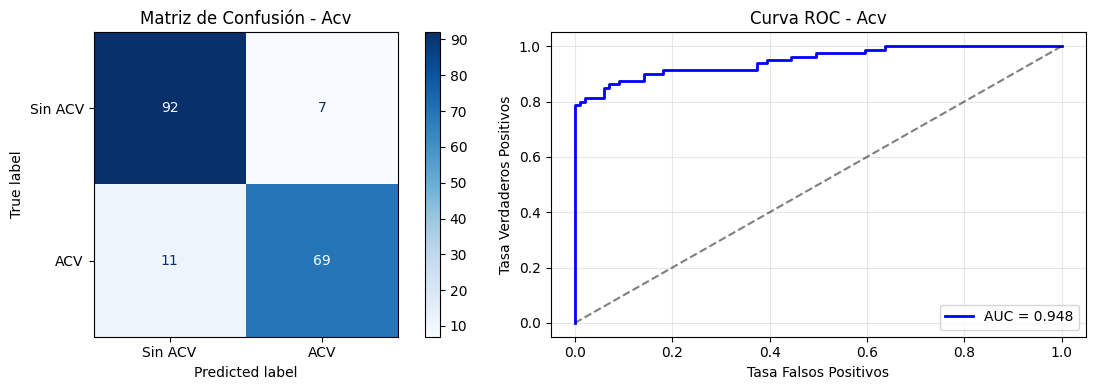


>>> FRACTURA <<<
Train: 411 negativos, 305 positivos (42.6%)
Epoch 1/20
38/38 - 14s - 368ms/step - accuracy: 0.6135 - loss: 0.6664 - val_accuracy: 0.6389 - val_loss: 0.6530
Epoch 2/20
38/38 - 11s - 300ms/step - accuracy: 0.7056 - loss: 0.5828 - val_accuracy: 0.7130 - val_loss: 0.5903
Epoch 3/20
38/38 - 34s - 907ms/step - accuracy: 0.6842 - loss: 0.5968 - val_accuracy: 0.7407 - val_loss: 0.4882
Epoch 4/20
38/38 - 41s - 1s/step - accuracy: 0.8799 - loss: 0.3196 - val_accuracy: 0.9167 - val_loss: 0.2287
Epoch 5/20
38/38 - 23s - 607ms/step - accuracy: 0.9293 - loss: 0.2350 - val_accuracy: 0.7500 - val_loss: 0.5314
Epoch 6/20
38/38 - 28s - 739ms/step - accuracy: 0.9046 - loss: 0.2703 - val_accuracy: 0.9167 - val_loss: 0.1978
Epoch 7/20
38/38 - 7s - 197ms/step - accuracy: 0.9523 - loss: 0.1654 - val_accuracy: 0.9537 - val_loss: 0.1463
Epoch 8/20
38/38 - 7s - 183ms/step - accuracy: 0.9079 - loss: 0.2522 - val_accuracy: 0.7593 - val_loss: 0.5012
Epoch 9/20
38/38 - 8s - 202ms/step - accuracy: 

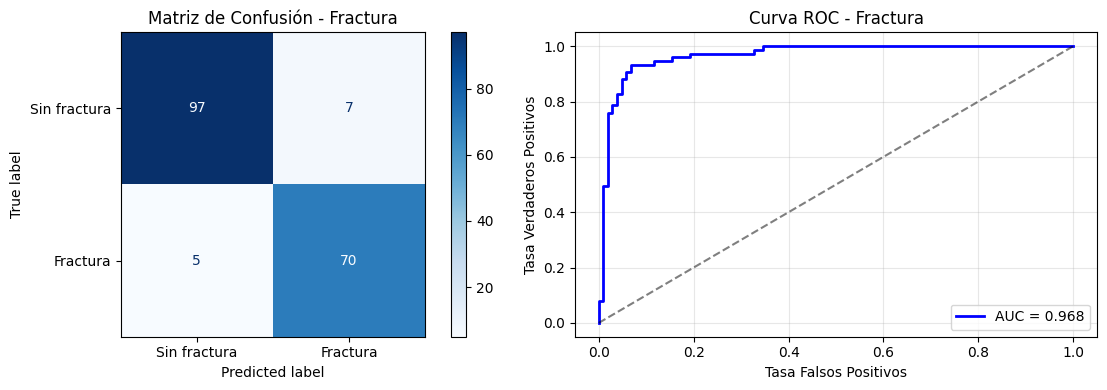


>>> MASA <<<
Train: 541 negativos, 175 positivos (24.4%)
Epoch 1/20
38/38 - 10s - 267ms/step - accuracy: 0.7500 - loss: 0.5872 - val_accuracy: 0.7963 - val_loss: 0.4678
Epoch 2/20
38/38 - 7s - 184ms/step - accuracy: 0.7993 - loss: 0.4336 - val_accuracy: 0.7500 - val_loss: 0.4328
Epoch 3/20
38/38 - 8s - 198ms/step - accuracy: 0.8947 - loss: 0.2769 - val_accuracy: 0.7593 - val_loss: 0.4807
Epoch 4/20
38/38 - 8s - 210ms/step - accuracy: 0.9424 - loss: 0.1695 - val_accuracy: 0.7870 - val_loss: 0.5035
Epoch 5/20
38/38 - 7s - 187ms/step - accuracy: 0.9326 - loss: 0.2062 - val_accuracy: 0.8889 - val_loss: 0.3592
Epoch 6/20
38/38 - 7s - 187ms/step - accuracy: 0.9688 - loss: 0.1191 - val_accuracy: 0.8426 - val_loss: 0.4374
Epoch 7/20
38/38 - 7s - 180ms/step - accuracy: 0.9819 - loss: 0.0684 - val_accuracy: 0.8704 - val_loss: 0.4111
Epoch 8/20
38/38 - 7s - 188ms/step - accuracy: 0.9819 - loss: 0.0671 - val_accuracy: 0.8704 - val_loss: 0.4339
Epoch 9/20
38/38 - 7s - 178ms/step - accuracy: 0.9901

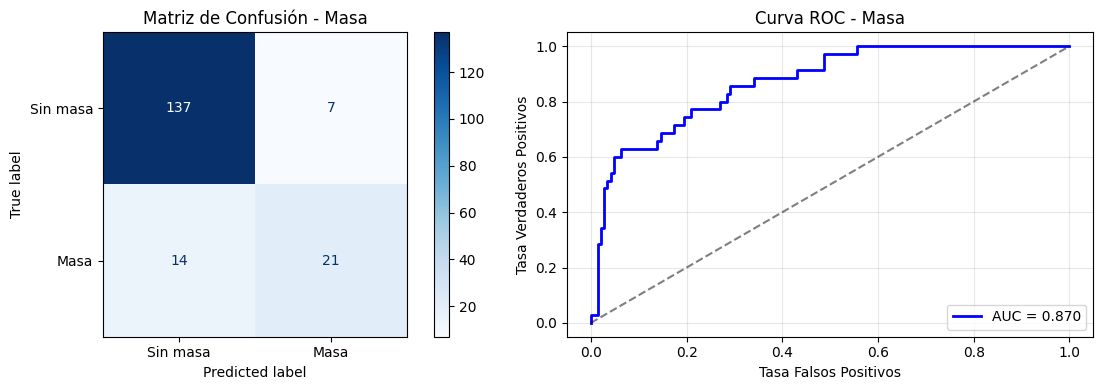

In [171]:
# Entrenar modelo por patología
modelos = {}
resultados = {}

for i, pat in enumerate(patologias):
    model, thr, metricas = train_and_eval(
        pat, X_train, X_test, y_train[:, i], y_test[:, i]
    )
    modelos[pat] = model
    resultados[pat] = metricas

In [163]:
# Resumen por patología
print("\n" + "="*70)
print("RESUMEN DE RESULTADOS LSTM")
print("="*70)
print(f"{'Patología':<15} {'AUC':>8} {'F1-Pos':>10} {'F1-Neg':>10}")
print("-"*70)
for pat in patologias:
    r = resultados[pat]
    print(f"{pat.capitalize():<15} {r['AUC']:>8.3f} {r['F1_pos']:>10.3f} {r['F1_neg']:>10.3f}")
print("="*70)

# AUC promedio
auc_promedio = np.mean([resultados[p]['AUC'] for p in patologias])
print(f"{'AUC Promedio':<15} {auc_promedio:>8.3f}")
print("="*70)


RESUMEN DE RESULTADOS LSTM
Patología            AUC     F1-Pos     F1-Neg
----------------------------------------------------------------------
Hemorragia         0.910      0.933      0.667
Acv                0.957      0.914      0.937
Fractura           0.939      0.868      0.903
Masa               0.914      0.719      0.939
AUC Promedio       0.930


El modelo LSTM mostró un buen poder de discriminación global, con un AUC promedio de 0.930, destacando especialmente en ACV (0.957) y fractura (0.939). En hemorragia, el modelo priorizó la detección de casos positivos (F1+ = 0.933), a costa de una menor capacidad para descartar casos negativos (F1− = 0.667), mientras que en masa, pese a un AUC alto (0.914), el desempeño en F1 positivo fue más bajo (0.719), reflejando la ambigüedad semántica de esta clase. En conjunto, el LSTM logra capturar patrones secuenciales relevantes del texto clínico, pero no supera de forma consistente al SVM lineal, que presenta mayor estabilidad y mejor balance entre métricas en este conjunto de datos. Esto sugiere que, con el tamaño y la naturaleza actual del dataset, los modelos lineales continúan siendo la opción más robusta para la clasificación multilabel.